In [1]:
try:
    from drought_ensemble.analysis.paper_figures import utils
    from drought_ensemble.classes import Domain
except ImportError:
    import sys
    from pathlib import Path

    def _find_project_root() -> Path:
        for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
            if (candidate / "classes" / "Domain.py").is_file():
                return candidate
            nested = candidate / "drought-ensemble"
            if (nested / "classes" / "Domain.py").is_file():
                return nested
        raise ImportError(
            "Install the project with `pip install -e .` from drought-ensemble/, "
            "or run this notebook from inside the project tree."
        )

    _root = _find_project_root()
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))

    from analysis.paper_figures import utils
    from classes import Domain

In [ ]:
domain_name = "wolf"
ensemble_name = "pumping_ensemble"
ensemble_member = "pumping_0_01"
PLOTTING_INTERVAL = 219

In [3]:
domain = Domain(domain_name, full_config_file_path_given=False)

In [4]:
data = utils.read_simulation_data(ensemble_name, ensemble_member, domain_name)
data.info()

/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfradial1' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'furuno' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'gamic' loading failed:
No module named 'xarray.core.merge'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/bwest/conda-envs/droughts/share/proj failed
/glade/work/bwest/conda-envs/droughts/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: 

xarray.Dataset {
dimensions:
	time = 157680 ;
	z = 10 ;
	y = 41 ;
	x = 78 ;

variables:
	float64 pressure(time, z, y, x) ;
	float64 saturation(time, z, y, x) ;
	float64 evaptrans(time, z, y, x) ;
	float64 overland_bc_flux(time, y, x) ;
	float64 mask(time, z, y, x) ;
	float64 mannings(time, y, x) ;
	float64 porosity(time, z, y, x) ;
	float64 specific_storage(time, z, y, x) ;
	float64 DZ_Multiplier(time, z, y, x) ;
	float64 slopex(time, y, x) ;
	float64 slopey(time, y, x) ;
	float64 perm_x(time, z, y, x) ;
	float64 perm_y(time, z, y, x) ;
	float64 perm_z(time, z, y, x) ;
	float64 overland_flow(time, y, x) ;
	float64 storage(time, z, y, x) ;
	float64 time(time) ;

// global attributes:
}

In [5]:

# data.overland_flow.isel(time=8760).plot()

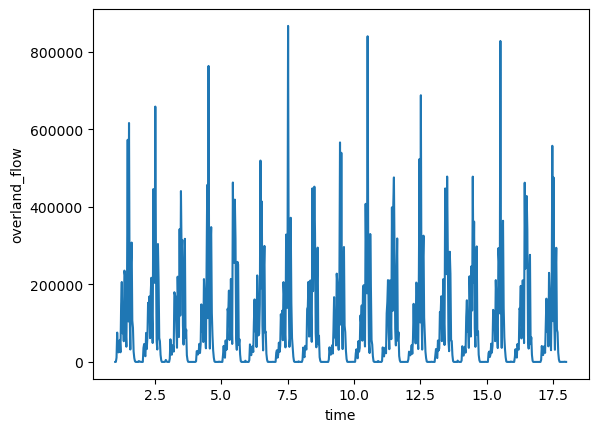

In [6]:
data.overland_flow.isel(
    x=domain.outlet_x, 
    y=domain.outlet_y, 
    time=slice(8760, None, PLOTTING_INTERVAL)
    ).plot()

In [7]:
# data.storage.isel(time=slice(0, None, PLOTTING_INTERVAL)).sum(dim=["x", "y", "z"]).plot()